# Titanic Dataset — Week 2: Data Cleaning & Visualization
**Track:** Neurofive ML Track — Week 2
**Goal:** Clean the messy parts of the Titanic dataset, catch outliers, and tell its story visually before any modeling.

This continues directly from the Week 1 EDA notebook, using the same dataset:
`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the dataset

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.shape


(891, 12)

## 3. Recap: missing values before cleaning

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]


Age         177
Cabin       687
Embarked      2
dtype: int64

## 4. Handling missing values

**My choices, and why:**

- **`Age` (177 missing, ~20%)** → fill with the **median age per `Pclass`** using `fillna()`. Age correlates with passenger class (wealthier/older passengers tended to book higher classes), so a per-class median is a more honest fill than one global median, and median avoids being skewed by the outliers in Age.
- **`Embarked` (2 missing)** → fill with the **mode** (most frequent port) using `fillna()`. Only 2 rows are affected, so the impact of a wrong guess is negligible, and mode is the standard simple approach for a categorical column with very few missing values.
- **`Cabin` (687 missing, ~77%)** → **drop the column** with a plan to engineer `has_cabin` instead of trying to fill it. Filling 77% of a column would mostly be fabricated data; the more honest and useful signal is *whether* a cabin was recorded at all, which likely correlates with ticket class/fare.

I avoided `dropna()` on rows because `Age` alone would cost ~20% of the dataset — too much signal to throw away when a justified fill works better.


In [4]:
df_clean = df.copy()

# Age: median per Pclass
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: engineer a binary flag, then drop the original column
df_clean['has_cabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

# Confirm no missing values remain in the columns we handled
df_clean[['Age', 'Embarked', 'has_cabin']].isnull().sum()


Age          0
Embarked     0
has_cabin    0
dtype: int64

In [5]:
print("Remaining missing values:")
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]


Remaining missing values:


Series([], dtype: int64)

## 5. Outlier detection — boxplot on `Fare`

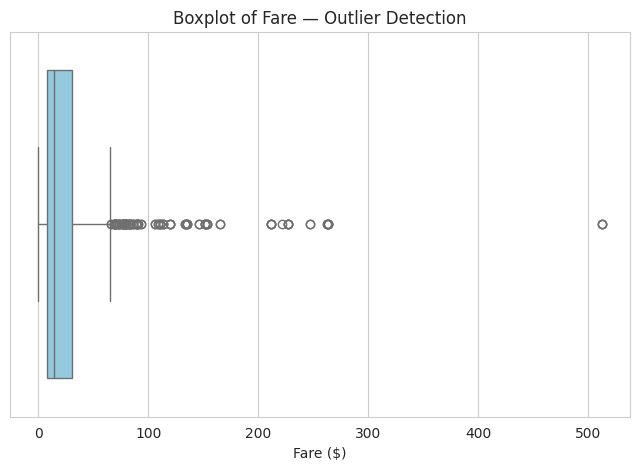

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['Fare'], color='skyblue')
plt.title('Boxplot of Fare — Outlier Detection')
plt.xlabel('Fare ($)')
plt.show()


**Observation:** `Fare` has a long right tail of outliers, several passengers paid well above \$100, with a few extreme values near \$500 (likely first-class group bookings). These are real values, not data errors, so I'm keeping them rather than removing them, but I'd consider a log transform before feeding `Fare` into a distance-based model.

## 6. Visualization 1 — Histogram: Age distribution

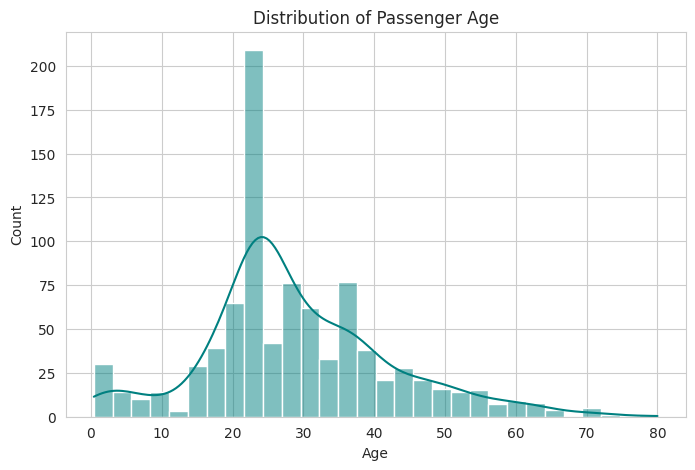

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='teal')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


## 7. Visualization 2 — Boxplot: Fare by Passenger Class

/tmp/ipykernel_560/3303157314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df_clean, palette='Set2')


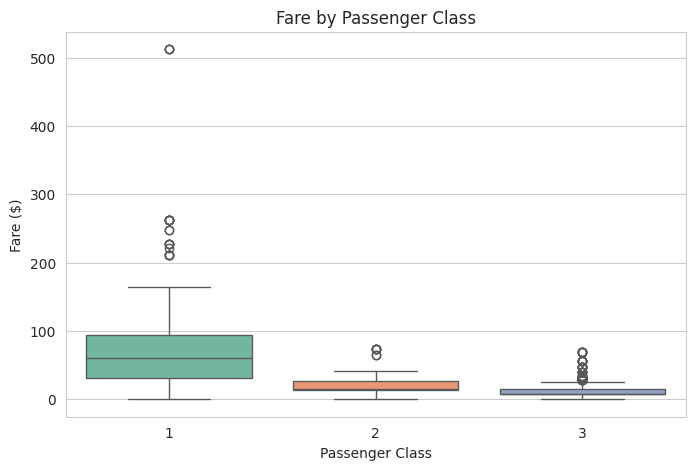

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=df_clean, palette='Set2')
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.show()


## 8. Visualization 3 — Bar chart: Survival Rate by Sex

/tmp/ipykernel_560/2152934005.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_clean, palette='pastel', errorbar=None)


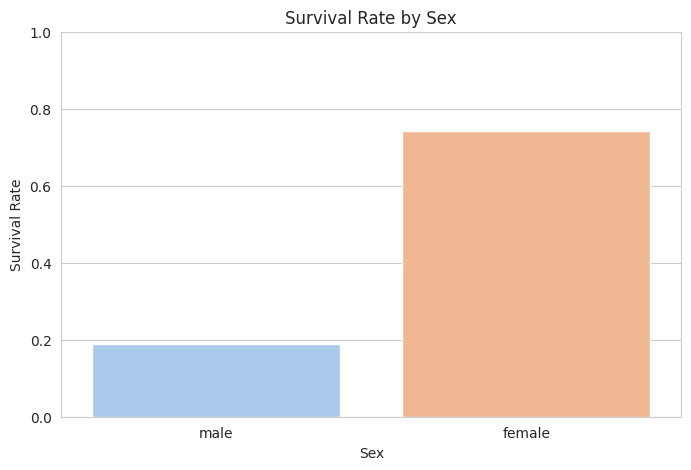

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=df_clean, palette='pastel', errorbar=None)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()


## 9. Visualization 4 — Correlation Heatmap

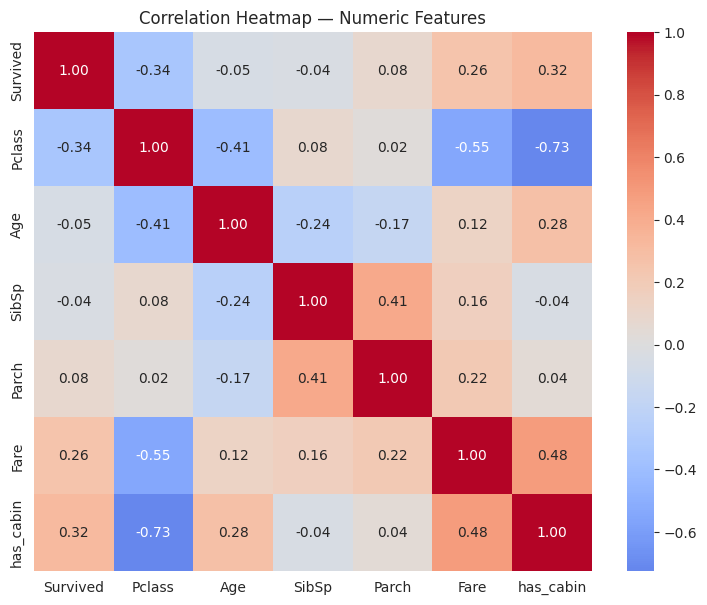

In [10]:
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])
corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()


## 10. Which feature most affects survival, and why?

Based on the visualizations above, **`Sex`** appears to be the feature most strongly associated with survival. The bar chart shows a large gap in survival rate between females and males — women survived at a much higher rate, consistent with the "women and children first" evacuation priority on the Titanic. `Pclass` and `Fare` are the next strongest signals: the heatmap shows a moderate negative correlation between `Pclass` and `Survived` (higher class number = lower survival) and a positive correlation between `Fare` and `Survived`, which makes sense since higher fares map to higher classes and those passengers had better access to lifeboats. `Age` shows a much weaker relationship on its own in the heatmap, though it likely matters more in combination with other features (e.g. children within a given class).

**Ranking:** `Sex` > `Pclass` / `Fare` > `Age`.


## 11. Summary — Week 2 Data Story

- Cleaned missing values in `Age` (per-class median), `Embarked` (mode), and `Cabin` (dropped, replaced with a `has_cabin` flag) — justified above rather than blindly using `dropna()`.
- The `Fare` boxplot revealed genuine right-tail outliers (up to ~$500) that reflect real high-fare bookings, not data errors, so they were kept.
- Four visualizations (histogram, boxplot, bar chart, heatmap) together tell a consistent story: survival was driven most by `Sex`, then by `Pclass`/`Fare`, with `Age` playing a smaller standalone role.
- The heatmap was the most surprising plot: it makes the `Pclass`/`Fare` relationship with survival explicit as numbers, not just visually, and confirms the pattern the bar chart hinted at for `Sex`.
- **Next step:** engineer a family-size feature from `SibSp` + `Parch`, and test whether it adds signal beyond what `Pclass` and `Sex` already capture.
